# 2. Analytical EDA

This notebook builds on the data-quality findings from `01_data_audit.ipynb` and moves into the business-facing analysis. The goal is to understand household purchasing behaviour, product and store performance, transaction trends, and promotional response, and then use those findings to support the promotional-investment framework.

The analysis is exploratory in nature. Rather than treating each metric in isolation, the results are used to understand where customer value is concentrated, where promotional activity appears most relevant, and which measurements require additional care before they are used for scoring.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
# Project paths
PROJECT_DIR = Path.cwd().parent
DATA_DIR = PROJECT_DIR / "data"

files = {
    "campaign_desc": "campaign_desc.csv",
    "campaign_table": "campaign_table.csv",
    "causal_data": "causal_data.csv",
    "coupon": "coupon.csv",
    "coupon_redeem": "coupon_redempt.csv",
    "hh_demographic": "hh_demographic.csv",
    "product": "product.csv",
    "transaction_data": "transaction_data.csv"
}

dfs = {}

for name, filename in files.items():
    dfs[name] = pd.read_csv(DATA_DIR / filename)

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [3]:
campaign_desc = dfs["campaign_desc"]
campaign_table = dfs["campaign_table"]
causal_data = dfs["causal_data"]
coupon = dfs["coupon"]
coupon_redeem = dfs["coupon_redeem"]
hh_demographic = dfs["hh_demographic"]
product = dfs["product"]
transaction = dfs["transaction_data"]

## 2.1 Transaction Overview

The analysis begins by establishing the scale and commercial profile of the transaction data. This provides the context needed to interpret the customer, product, store, and promotional analysis that follows.

The overview covers total sales, purchasing activity, households, products, stores, and the time period represented in the dataset.


In [4]:
transaction_overview = pd.DataFrame({
    "Metric": [
        "Total transaction records",
        "Total sales",
        "Total quantity",
        "Unique households",
        "Unique products",
        "Unique stores",
        "Unique transaction days",
        "Unique weeks",
        "Average sales per transaction",
        "Average quantity per transaction"
    ],
    "Value": [
        len(transaction),
        transaction["SALES_VALUE"].sum(),
        transaction["QUANTITY"].sum(),
        transaction["household_key"].nunique(),
        transaction["PRODUCT_ID"].nunique(),
        transaction["STORE_ID"].nunique(),
        transaction["DAY"].nunique(),
        transaction["WEEK_NO"].nunique(),
        transaction["SALES_VALUE"].mean(),
        transaction["QUANTITY"].mean()
    ]
})

transaction_overview

,Metric,Value
0,Total transaction records,"2,595,732.00"
1,Total sales,"8,057,463.08"
2,Total quantity,"260,685,622.00"
3,Unique households,"2,500.00"
4,Unique products,"92,339.00"
5,Unique stores,582.00
6,Unique transaction days,711.00
7,Unique weeks,102.00
8,Average sales per transaction,3.10
9,Average quantity per transaction,100.43


## 2.2 Transaction & Sales Trends

The next step is to examine how sales and transaction activity change over the observed period. Weekly trends help distinguish the underlying sales pattern from short-term fluctuations and provide a baseline for the more detailed product, store, and campaign analysis that follows.


In [5]:
weekly_trends = (
    transaction
    .groupby("WEEK_NO")
    .agg(
        transactions=("BASKET_ID", "nunique"),
        sales=("SALES_VALUE", "sum"),
        quantity=("QUANTITY", "sum"),
        households=("household_key", "nunique")
    )
    .reset_index()
)

weekly_trends.head()

,WEEK_NO,transactions,sales,quantity,households
0,1,142,"5,211.16",2353,88
1,2,324,"10,821.35",7223,175
2,3,482,"13,498.20",57776,228
3,4,545,"15,965.99",76865,270
4,5,757,"20,139.82",101706,370


In [6]:
weekly_trends[["transactions", "sales", "quantity", "households"]].describe()

,transactions,sales,quantity,households
count,102.00,102.00,102.00,102.00
mean,"2,710.63","78,994.74","2,555,741.39","1,215.45"
std,682.27,"20,944.80","851,552.46",291.57
min,142.00,"5,211.16","2,353.00",88.00
25%,"2,841.25","79,295.78","2,472,944.50","1,284.25"
50%,"2,936.00","84,936.74","2,834,607.50","1,313.00"
75%,"3,005.75","89,641.11","3,032,820.00","1,337.75"
max,"3,362.00","113,192.87","3,469,176.00","1,428.00"


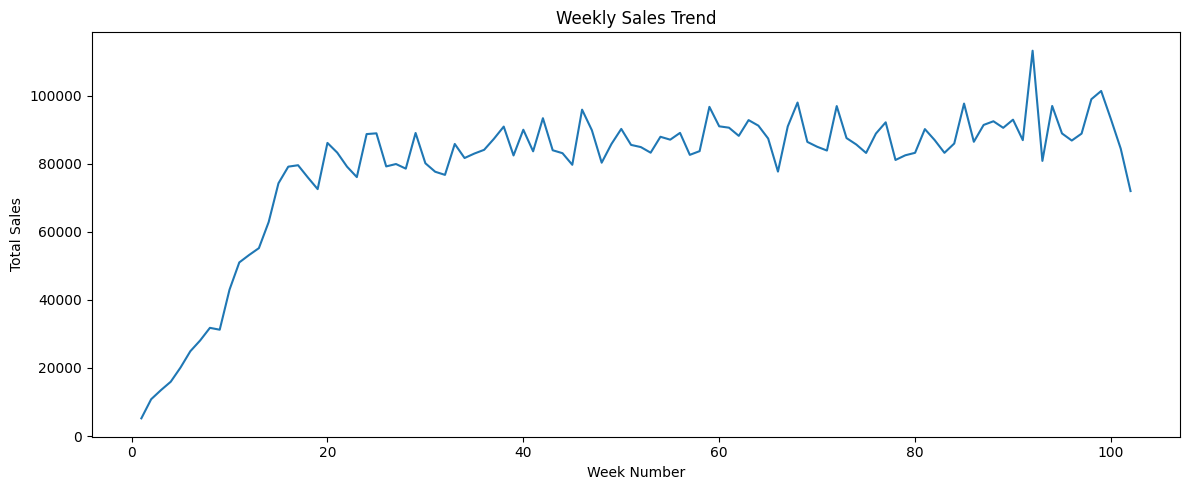

In [7]:
plt.figure(figsize=(12, 5))

plt.plot(
    weekly_trends["WEEK_NO"],
    weekly_trends["sales"]
)

plt.title("Weekly Sales Trend")
plt.xlabel("Week Number")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

### Key Observations

The weekly view shows a rapid increase in sales during the initial weeks, followed by a more stable pattern. After this early growth phase, weekly sales generally remain within the ~$80K–$100K range, although some weeks move above $110K while others fall below the typical range.

These movements should be considered alongside transaction volume and household participation. Doing so helps distinguish changes caused by customer activity from changes in transaction value. The variation also provides a reason to examine product, store, and campaign-level behaviour rather than attributing the overall movement to a single factor.


## 2.3 Product Performance

With the overall transaction base established, attention turns to the product level to understand which products contribute most to sales and how concentrated product-level revenue is.


In [8]:
product_performance = (
    transaction
    .groupby("PRODUCT_ID")
    .agg(
        sales=("SALES_VALUE", "sum"),
        quantity=("QUANTITY", "sum"),
        transactions=("BASKET_ID", "nunique"),
        households=("household_key", "nunique")
    )
    .sort_values("sales", ascending=False)
)

product_performance.head(20)

,sales,quantity,transactions,households
PRODUCT_ID,,,,
6534178,"503,867.11",216532156,19820,1312
6533889,"46,311.32",18479630,1453,151
1029743,"41,072.06",16976,14430,1387
6534166,"33,594.48",13980451,1206,189
1082185,"29,482.00",30896,29778,2069
916122,"28,951.93",6985,4415,1154
6533765,"28,837.27",1756,1756,333
1106523,"27,818.44",11500,9826,1040
995242,"26,502.46",21758,12542,1465


In [9]:
product_performance.describe()

,sales,quantity,transactions,households
count,"92,339.00","92,339.00","92,339.00","92,339.00"
mean,87.26,"2,823.14",28.11,15.18
std,"1,722.82","716,737.45",191.96,47.30
min,0.00,0.00,1.00,1.00
25%,3.50,1.00,1.00,1.00
50%,10.89,3.00,3.00,2.00
75%,47.13,15.00,13.00,10.00
max,"503,867.11","216,532,156.00","29,778.00","2,069.00"


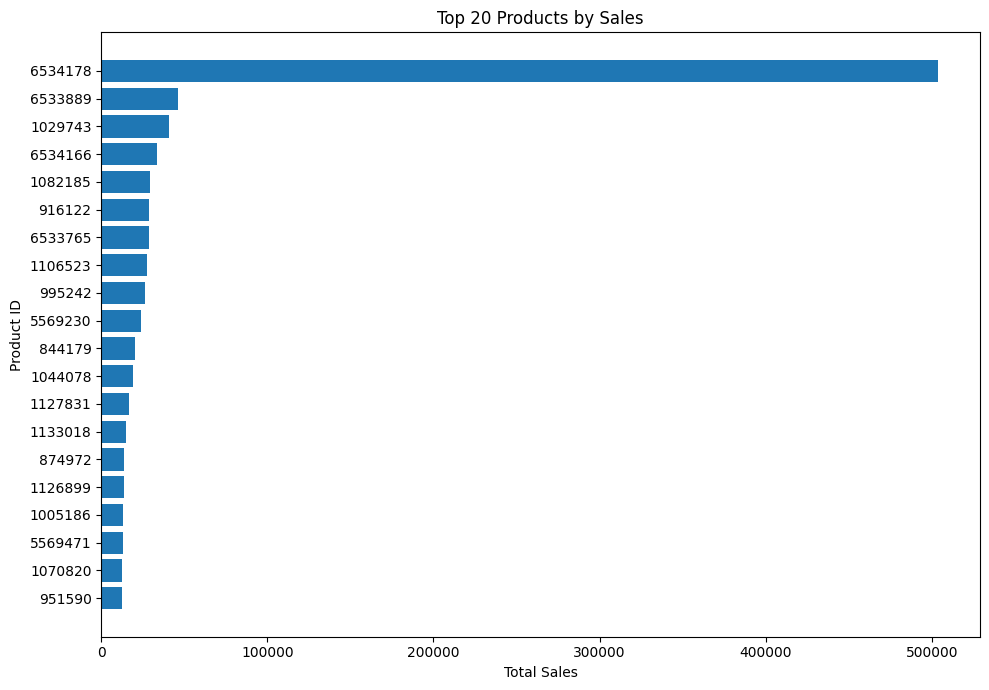

In [10]:
top_products = product_performance.head(20).sort_values("sales")

plt.figure(figsize=(10, 7))

plt.barh(
    top_products.index.astype(str),
    top_products["sales"]
)

plt.title("Top 20 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product ID")

plt.tight_layout()
plt.show()


In [11]:
transaction.loc[
    transaction["PRODUCT_ID"] == 6534178,
    ["PRODUCT_ID", "SALES_VALUE", "QUANTITY", "BASKET_ID", "DAY"]
].describe()

,PRODUCT_ID,SALES_VALUE,QUANTITY,BASKET_ID,DAY
count,"19,820.00","19,820.00","19,820.00","19,820.00","19,820.00"
mean,"6,534,178.00",25.42,"10,924.93","34,118,649,402.58",395.43
std,0.00,12.26,"5,099.82","4,603,923,166.33",183.06
min,"6,534,178.00",0.03,10.00,"27,115,512,637.00",12.00
25%,"6,534,178.00",17.06,"7,357.00","30,532,531,074.50",235.00
50%,"6,534,178.00",24.48,"10,568.00","32,956,638,078.00",402.00
75%,"6,534,178.00",32.50,"14,104.25","40,097,574,854.75",551.00
max,"6,534,178.00",250.00,"89,638.00","42,289,894,300.00",711.00


In [12]:
transaction.loc[
    transaction["PRODUCT_ID"] == 6534178
].head(20)

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
5378,932,27115512637,12,6534178,995,2.18,422,-0.01,1745,2,0.00,0.00
5380,932,27115512702,12,6534178,1461,3.20,422,-0.01,1757,2,0.00,0.00
6213,778,27130432788,13,6534178,2416,5.00,310,-0.24,1838,3,0.00,0.00
6674,778,27130955980,14,6534178,2728,6.00,422,-0.27,1222,3,0.00,0.00
7198,778,27153895714,15,6534178,8737,20.00,310,-0.01,1147,3,0.00,0.00
8055,988,27176877230,17,6534178,11066,23.01,408,-1.10,1845,3,0.00,0.00
8866,784,27190560195,18,6534178,5598,12.20,408,-0.01,908,3,0.00,0.00
9201,1455,27190875400,18,6534178,9026,20.03,341,0.00,1025,3,0.00,0.00
10264,778,27191462009,19,6534178,12025,25.00,310,-1.20,1550,3,0.00,0.00
10508,245,27213100863,20,6534178,9255,20.07,408,-0.01,1323,4,0.00,0.00


In [13]:
top_product = product_performance.loc[6534178]

pd.Series({
    "sales_share": top_product["sales"] / transaction["SALES_VALUE"].sum(),
    "quantity_share": top_product["quantity"] / transaction["QUANTITY"].sum()
})

sales_share      0.06
quantity_share   0.83
dtype: float64

### 2.3 Product Concentration & Anomaly Analysis

One product stands out immediately. Product 6534178 contributes approximately 6% of total sales but accounts for approximately 83% of recorded quantity.

The gap between its quantity share and sales share suggests that its measurement context is different from that of typical grocery products. We therefore examine this product more closely before allowing raw quantity to influence downstream conclusions.


In [14]:
top_product = product_performance.loc[6534178]

product_concentration = pd.Series({
    "sales_share": top_product["sales"] / transaction["SALES_VALUE"].sum(),
    "quantity_share": top_product["quantity"] / transaction["QUANTITY"].sum(),
    "transaction_share": top_product["transactions"] / transaction["BASKET_ID"].nunique(),
    "household_share": top_product["households"] / transaction["household_key"].nunique()
})

product_concentration

sales_share         0.06
quantity_share      0.83
transaction_share   0.07
household_share     0.52
dtype: float64

In [15]:
product_comparison = pd.Series({
    "Top product avg quantity per transaction": (
        top_product["quantity"] / top_product["transactions"]
    ),
    "Overall avg quantity per transaction": (
        transaction["QUANTITY"].sum() / transaction["BASKET_ID"].nunique()
    ),
    "Top product avg sales per transaction": (
        top_product["sales"] / top_product["transactions"]
    ),
    "Overall avg sales per transaction": (
        transaction["SALES_VALUE"].sum() / transaction["BASKET_ID"].nunique()
    )
})

product_comparison

Top product avg quantity per transaction   10,924.93
Overall avg quantity per transaction          942.86
Top product avg sales per transaction          25.42
Overall avg sales per transaction              29.14
dtype: float64

In [16]:
top_product_unit_value = pd.Series({
    "Top product sales per unit": (
        top_product["sales"] / top_product["quantity"]
    ),
    "Overall sales per unit": (
        transaction["SALES_VALUE"].sum() / transaction["QUANTITY"].sum()
    )
})

print(f"Top product sales per unit: {top_product['sales'] / top_product['quantity']:.5f}")
print(f"Overall sales per unit: {transaction['SALES_VALUE'].sum() / transaction['QUANTITY'].sum():.5f}")

Top product sales per unit: 0.00233
Overall sales per unit: 0.03091


### Product Performance Insights

Product 6534178 is the highest-sales product, contributing approximately 6% of total sales, while also accounting for approximately 83% of total recorded quantity. It appears in transactions associated with approximately 52% of households, so the behaviour is not limited to a small customer group.

Its average quantity per transaction is substantially higher than the overall transaction average, while average sales per transaction is lower. This creates a distinct volume-to-value profile: the product generates substantial recorded volume without a proportionate contribution to sales. That difference becomes important later when we decide which measures can be compared reliably across products and categories.


## 2.4 Store Performance

The analysis now moves from products to stores, examining how performance differs across sales, transaction activity, quantity, and household reach. The aim is to distinguish stores that generate value consistently from those that appear strong only on a single volume or efficiency measure.

The analysis therefore considers top sales contributors, customer reach, transaction and quantity volume, and store-level efficiency.


In [17]:
store_performance = (
    transaction
    .groupby("STORE_ID")
    .agg(
        sales=("SALES_VALUE", "sum"),
        quantity=("QUANTITY", "sum"),
        transactions=("BASKET_ID", "nunique"),
        households=("household_key", "nunique")
    )
    .sort_values("sales", ascending=False)
)

store_performance.head(10)

,sales,quantity,transactions,households
STORE_ID,,,,
367,"267,614.34",12743472,7724,264
406,"216,781.77",16044214,5422,134
361,"144,698.85",9012499,5146,98
429,"142,391.01",16860489,3883,99
343,"140,455.75",9582406,5141,237
356,"137,588.68",64388,4266,111
381,"132,488.15",62238,5047,278
375,"130,396.51",14993687,4110,217
292,"130,005.18",61243,3975,194


In [18]:
store_performance.describe()

,sales,quantity,transactions,households
count,582.00,582.00,582.00,582.00
mean,"13,844.44","447,913.44",475.06,23.47
std,"32,845.13","1,897,852.12","1,091.26",48.79
min,0.00,1.00,1.00,1.00
25%,27.97,14.00,1.00,1.00
50%,100.93,104.00,4.00,2.00
75%,992.64,"22,073.75",41.00,6.00
max,"267,614.34","16,860,489.00","7,724.00",278.00


### 2.4.1 Top Stores by Sales

We first identify the stores generating the most sales and use the result to assess whether revenue is concentrated among a small number of locations or distributed more broadly across the store network.


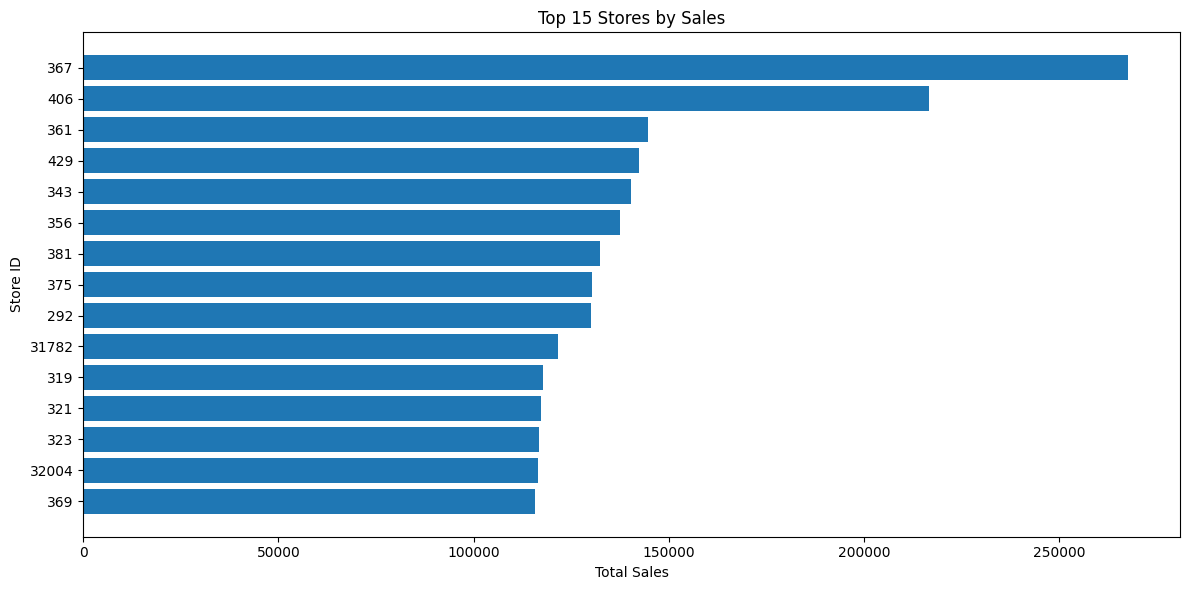

In [19]:
top_stores = (
    store_performance
    .head(15)
    .sort_values("sales")
)

plt.figure(figsize=(12, 6))

plt.barh(
    top_stores.index.astype(str),
    top_stores["sales"]
)

plt.title("Top 15 Stores by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Store ID")
plt.tight_layout()
plt.show()

In [20]:
top_10_store_sales_share = (
    store_performance.head(10)["sales"].sum()
    / transaction["SALES_VALUE"].sum()
)

print(f"Top 10 stores sales share: {top_10_store_sales_share:.2%}")

Top 10 stores sales share: 19.41%


## 2.4.1 Key Insights

Store 367 is the highest-sales store, generating approximately 267.6K in total sales, followed by Store 406 at approximately 216.8K. The top 10 stores together contribute 19.41% of total sales.

This indicates that sales are relatively distributed across the store network rather than being dominated by a small number of locations.


## 2.4.2 Store Performance Comparison

Sales alone do not fully describe store performance. Sales are therefore compared with quantity, transaction volume, and household reach to determine whether the stores generating the most revenue also lead on customer activity and purchasing volume.


In [21]:
store_comparison = store_performance.copy()

store_comparison["sales_per_transaction"] = (
    store_comparison["sales"] / store_comparison["transactions"]
)

store_comparison["quantity_per_transaction"] = (
    store_comparison["quantity"] / store_comparison["transactions"]
)

store_comparison["sales_per_household"] = (
    store_comparison["sales"] / store_comparison["households"]
)

store_comparison.sort_values("sales", ascending=False).head(10)

,sales,quantity,transactions,households,sales_per_transaction,quantity_per_transaction,sales_per_household
STORE_ID,,,,,,,
367,"267,614.34",12743472,7724,264,34.65,"1,649.85","1,013.69"
406,"216,781.77",16044214,5422,134,39.98,"2,959.10","1,617.77"
361,"144,698.85",9012499,5146,98,28.12,"1,751.36","1,476.52"
429,"142,391.01",16860489,3883,99,36.67,"4,342.13","1,438.29"
343,"140,455.75",9582406,5141,237,27.32,"1,863.92",592.64
356,"137,588.68",64388,4266,111,32.25,15.09,"1,239.54"
381,"132,488.15",62238,5047,278,26.25,12.33,476.58
375,"130,396.51",14993687,4110,217,31.73,"3,648.10",600.91
292,"130,005.18",61243,3975,194,32.71,15.41,670.13


In [22]:
store_efficiency = pd.Series({
    "Highest sales per transaction": store_comparison["sales_per_transaction"].idxmax(),
    "Highest quantity per transaction": store_comparison["quantity_per_transaction"].idxmax(),
    "Highest sales per household": store_comparison["sales_per_household"].idxmax()
})

store_efficiency

Highest sales per transaction        278
Highest quantity per transaction    3065
Highest sales per household         3235
dtype: int64

In [23]:
store_efficiency_details = store_comparison.loc[
    [278, 3065, 3235],
    [
        "sales",
        "quantity",
        "transactions",
        "households",
        "sales_per_transaction",
        "quantity_per_transaction",
        "sales_per_household"
    ]
]

store_efficiency_details

,sales,quantity,transactions,households,sales_per_transaction,quantity_per_transaction,sales_per_household
STORE_ID,,,,,,,
278,212.19,70,1,1,212.19,70.00,212.19
3065,72.00,24007,1,1,72.00,"24,007.00",72.00
3235,"4,788.97",63429,100,1,47.89,634.29,"4,788.97"


### Store Efficiency Insights

The efficiency measures reveal why store performance needs to be interpreted in context. Store 278 has the highest sales per transaction (₹212.19), but this comes from only one transaction and is therefore an outlier rather than evidence of sustained performance.

Similarly, Store 3065 records the highest quantity per transaction (24,007 units) from a single transaction, making the metric highly sensitive to transaction volume. Store 3235 provides a more meaningful efficiency signal, generating the highest sales per household (₹4,788.97) across 100 households.

The broader lesson is that efficiency metrics should always be considered alongside their underlying transaction and household counts.


## 2.4.3 Store Volume vs. Value

The relationship between recorded quantity and sales is examined at the store level. This helps determine whether higher-volume stores also generate higher monetary value and highlights stores where the relationship between volume and value is unusually strong or weak.

The comparison focuses on the relationship between quantity and sales, high-volume/low-value stores, high-value stores relative to their volume, and potential outliers that warrant further investigation.


In [24]:
store_value_analysis = store_performance.copy()

store_value_analysis["sales_per_unit"] = (
    store_value_analysis["sales"] /
    store_value_analysis["quantity"]
)

store_value_analysis["quantity_share"] = (
    store_value_analysis["quantity"] /
    store_performance["quantity"].sum()
)

store_value_analysis["sales_share"] = (
    store_value_analysis["sales"] /
    store_performance["sales"].sum()
)

store_value_analysis.head(10)

,sales,quantity,transactions,households,sales_per_unit,quantity_share,sales_share
STORE_ID,,,,,,,
367,"267,614.34",12743472,7724,264,0.02,0.05,0.03
406,"216,781.77",16044214,5422,134,0.01,0.06,0.03
361,"144,698.85",9012499,5146,98,0.02,0.03,0.02
429,"142,391.01",16860489,3883,99,0.01,0.06,0.02
343,"140,455.75",9582406,5141,237,0.01,0.04,0.02
356,"137,588.68",64388,4266,111,2.14,0.00,0.02
381,"132,488.15",62238,5047,278,2.13,0.00,0.02
375,"130,396.51",14993687,4110,217,0.01,0.06,0.02
292,"130,005.18",61243,3975,194,2.12,0.00,0.02


In [25]:
correlation = store_value_analysis["sales"].corr(
    store_value_analysis["quantity"]
)

print(f"Correlation between store sales and quantity: {correlation:.3f}")

Correlation between store sales and quantity: 0.704


In [26]:
high_volume_stores = (
    store_value_analysis
    .sort_values("quantity", ascending=False)
    .head(10)
)

high_volume_stores[
    ["sales", "quantity", "transactions", "sales_per_unit"]
]

,sales,quantity,transactions,sales_per_unit
STORE_ID,,,,
429,"142,391.01",16860489,3883,0.01
406,"216,781.77",16044214,5422,0.01
375,"130,396.51",14993687,4110,0.01
367,"267,614.34",12743472,7724,0.02
323,"116,672.42",10552648,3783,0.01
343,"140,455.75",9582406,5141,0.01
361,"144,698.85",9012499,5146,0.02
319,"117,782.21",8515166,4555,0.01
384,"101,058.79",8263507,2841,0.01


In [27]:
quantity_median = store_value_analysis["quantity"].median()
sales_median = store_value_analysis["sales"].median()

high_volume_low_value = store_value_analysis[
    (store_value_analysis["quantity"] > quantity_median) &
    (store_value_analysis["sales"] < sales_median)
].sort_values("quantity", ascending=False)

high_volume_low_value[
    ["sales", "quantity", "transactions", "sales_per_unit"]
].head(10)

,sales,quantity,transactions,sales_per_unit
STORE_ID,,,,
580,92.30,36849,6,0.00
3091,72.04,24035,3,0.00
3065,72.00,24007,1,0.00
2981,75.67,23011,7,0.00
489,51.60,22842,1,0.00
3385,51.98,22452,1,0.00
32310,73.24,22415,3,0.00
3135,70.18,22142,2,0.00
3013,75.42,20288,2,0.00


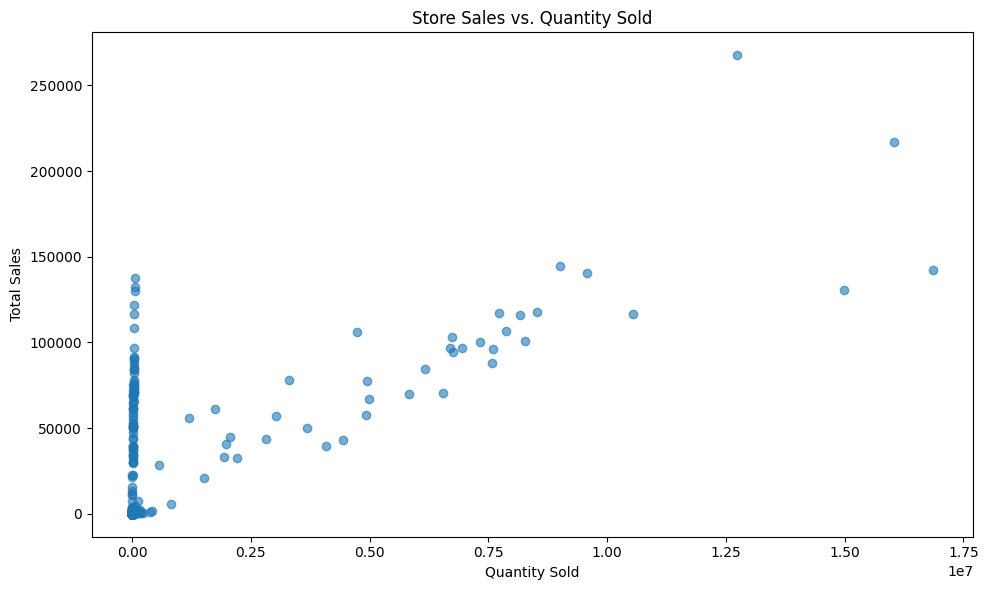

In [28]:
plt.figure(figsize=(10, 6))

plt.scatter(
    store_value_analysis["quantity"],
    store_value_analysis["sales"],
    alpha=0.6
)

plt.xlabel("Quantity Sold")
plt.ylabel("Total Sales")
plt.title("Store Sales vs. Quantity Sold")
plt.tight_layout()
plt.show()

## Store Volume vs. Value Insights

Store sales and recorded quantity have a positive correlation of approximately 0.70, so higher-volume stores generally generate higher sales. The relationship is not proportional, however.

Stores such as 580, 3091, 3065, and 2981 record relatively high quantities but very low sales values, resulting in extremely low sales-per-unit measures. In contrast, stores such as 356, 381, 292, and 31782 generate substantially more sales relative to their recorded quantities.

The comparison reinforces that no single volume metric is sufficient for evaluating stores. Sales, quantity, transactions, and sales-per-unit need to be considered together, while the extreme volume-to-value differences should be investigated for possible underlying data characteristics.


## 2.4 Store Performance - Key Insights

The store analysis shows a broad performance distribution rather than a business dominated by a handful of locations. Store 367 leads sales at approximately 267.6K, followed by stores 406 and 361, while the top 10 stores contribute approximately 19.41% of total sales.

Efficiency also varies considerably. Store 278 leads sales per transaction and Store 3065 leads recorded quantity per transaction, but both results are based on single transactions and should therefore be treated as outliers. Store 3235 records the highest sales per household, highlighting differences in customer value across locations.

Overall store sales and quantity have a correlation of approximately 0.70, but several stores show unusually high recorded quantities relative to sales. Store performance should therefore be assessed using multiple measures, with the extreme volume-to-value patterns carried forward for further data-quality interpretation.


## 2.5 Household Performance & Customer Concentration

The focus now shifts from locations to customers. Purchasing behaviour is aggregated at the household level to understand how revenue is distributed across the customer base and whether a relatively small group of households contributes disproportionately to sales.

The section covers high-value households, sales concentration, purchasing frequency, and the relationship between spending and transaction activity.


### 2.5.1 Household-Level Sales Summary

We aggregate the transaction data by household to establish a consistent view of total sales, quantity purchased, and transaction frequency for each customer.


In [29]:
household_performance = (
    transaction
    .groupby("household_key")
    .agg(
        sales=("SALES_VALUE", "sum"),
        quantity=("QUANTITY", "sum"),
        transactions=("BASKET_ID", "nunique")
    )
)

household_performance["sales_per_transaction"] = (
    household_performance["sales"] /
    household_performance["transactions"]
)

household_performance["quantity_per_transaction"] = (
    household_performance["quantity"] /
    household_performance["transactions"]
)

household_performance.sort_values(
    "sales",
    ascending=False
).head(10)

,sales,quantity,transactions,sales_per_transaction,quantity_per_transaction
household_key,,,,,
1023,"38,319.79",4479917,603,63.55,"7,429.38"
1609,"27,859.68",2146715,412,67.62,"5,210.47"
2322,"23,646.92",992718,323,73.21,"3,073.43"
1453,"21,661.29",95743,761,28.46,125.81
2459,"20,671.50",488789,971,21.29,503.39
1430,"20,352.99",1741892,344,59.17,"5,063.64"
718,"19,299.86",869732,599,32.22,"1,451.97"
707,"19,194.42",1640193,498,38.54,"3,293.56"
1653,"19,153.75",1065654,541,35.40,"1,969.79"


### 2.5.2 Top Households by Sales

We then identify the households generating the highest sales and use their contribution to assess how concentrated customer value is across the base.


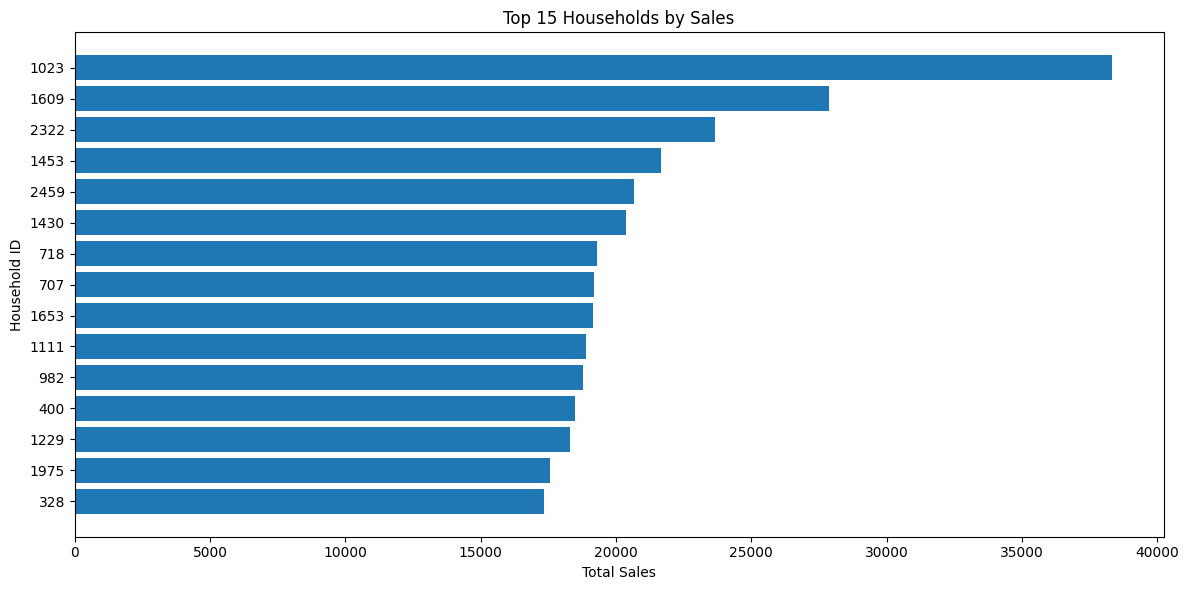

In [30]:
top_households = (
    household_performance
    .sort_values("sales", ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))

plt.barh(
    top_households.index.astype(str)[::-1],
    top_households["sales"][::-1]
)

plt.title("Top 15 Households by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Household ID")
plt.tight_layout()
plt.show()

### 2.5.3 Household Sales Concentration

To quantify customer concentration, the share of total sales generated by the top 1%, 5%, and 10% of households is measured. This provides a clearer view of how dependent overall revenue is on the highest-value part of the customer base.


In [31]:
household_sales_sorted = (
    household_performance["sales"]
    .sort_values(ascending=False)
)

total_household_sales = household_sales_sorted.sum()
total_households = len(household_sales_sorted)

top_1_pct_count = max(1, int(total_households * 0.01))
top_5_pct_count = max(1, int(total_households * 0.05))
top_10_pct_count = max(1, int(total_households * 0.10))

top_1_share = (
    household_sales_sorted.head(top_1_pct_count).sum()
    / total_household_sales
)

top_5_share = (
    household_sales_sorted.head(top_5_pct_count).sum()
    / total_household_sales
)

top_10_share = (
    household_sales_sorted.head(top_10_pct_count).sum()
    / total_household_sales
)

print(f"Top 1% households sales share: {top_1_share:.2%}")
print(f"Top 5% households sales share: {top_5_share:.2%}")
print(f"Top 10% households sales share: {top_10_share:.2%}")

Top 1% households sales share: 6.01%
Top 5% households sales share: 21.07%
Top 10% households sales share: 34.29%


### 2.5.4 Household Value Segmentation

Households are segmented using total sales and transaction activity so that high-value behaviour can be distinguished from simple purchase frequency.

This provides separate visibility into households with strong overall contribution, households that shop frequently, households with relatively high transaction value, and lower-value households that may require a more selective engagement strategy.


In [32]:
sales_median = household_performance["sales"].median()
transactions_median = household_performance["transactions"].median()

household_performance["value_segment"] = "Low Value"

household_performance.loc[
    (household_performance["sales"] >= sales_median) &
    (household_performance["transactions"] >= transactions_median),
    "value_segment"
] = "High Value - Frequent"

household_performance.loc[
    (household_performance["sales"] >= sales_median) &
    (household_performance["transactions"] < transactions_median),
    "value_segment"
] = "High Value - Less Frequent"

household_performance.loc[
    (household_performance["sales"] < sales_median) &
    (household_performance["transactions"] >= transactions_median),
    "value_segment"
] = "Low Value - Frequent"

household_performance["value_segment"].value_counts()

value_segment
High Value - Frequent         1050
Low Value                     1045
Low Value - Frequent           205
High Value - Less Frequent     200
Name: count, dtype: int64

### 2.5.5 High-Value Household Profile

We compare the highest-value households using total sales, transaction frequency, and average transaction value. This helps distinguish households whose value comes from frequent shopping from those whose value is driven by larger individual purchases.


In [33]:
household_summary = (
    household_performance
    .sort_values("sales", ascending=False)
    .head(10)
)

household_summary[
    [
        "sales",
        "quantity",
        "transactions",
        "sales_per_transaction"
    ]
]

,sales,quantity,transactions,sales_per_transaction
household_key,,,,
1023,"38,319.79",4479917,603,63.55
1609,"27,859.68",2146715,412,67.62
2322,"23,646.92",992718,323,73.21
1453,"21,661.29",95743,761,28.46
2459,"20,671.50",488789,971,21.29
1430,"20,352.99",1741892,344,59.17
718,"19,299.86",869732,599,32.22
707,"19,194.42",1640193,498,38.54
1653,"19,153.75",1065654,541,35.40


### 2.5.6 Household Sales vs. Transaction Frequency

The relationship between household transaction frequency and total sales is examined to clarify the role of purchase frequency in explaining household value.


In [34]:
correlation = household_performance[
    ["sales", "transactions"]
].corr().loc["sales", "transactions"]

print(
    f"Correlation between household sales and transaction frequency: "
    f"{correlation:.3f}"
)

Correlation between household sales and transaction frequency: 0.703


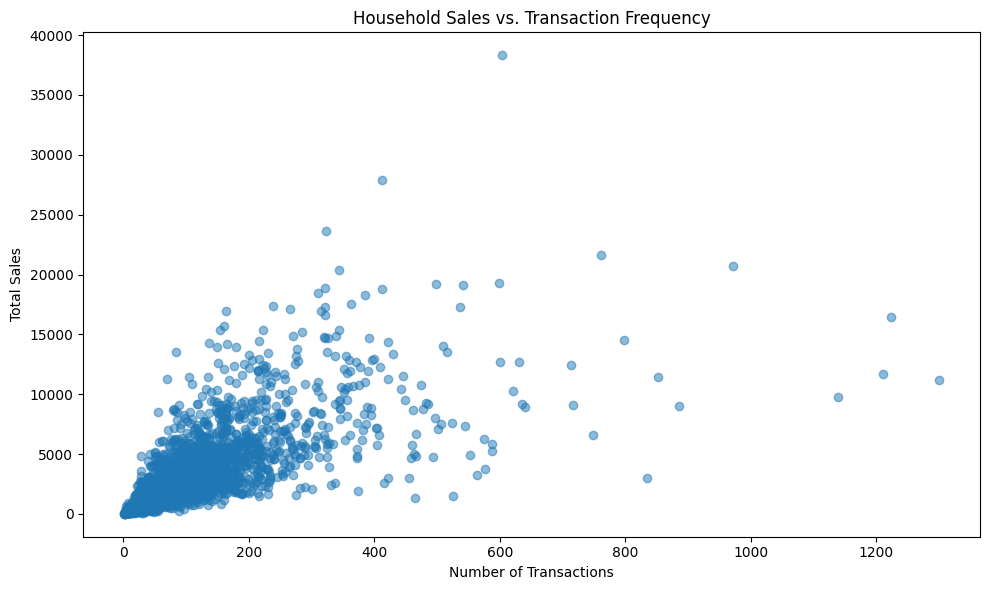

In [35]:
plt.figure(figsize=(10, 6))

plt.scatter(
    household_performance["transactions"],
    household_performance["sales"],
    alpha=0.5
)

plt.title("Household Sales vs. Transaction Frequency")
plt.xlabel("Number of Transactions")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

### 2.5 Household Performance Insights

Customer value is meaningfully concentrated, but not excessively so. The top 10% of households account for 34.3% of total sales, while the top 5% and top 1% account for 21.1% and 6.0%, respectively.

This indicates that a clear high-value customer group exists alongside a broad revenue base. High-sales households also tend to show stronger transaction frequency and basket contribution, making them natural candidates for targeted promotional investment.

At the other end of the distribution, the long tail of lower-spending households suggests that broad, undifferentiated couponing may be inefficient. The scoring framework therefore focuses on identifying where promotional investment is most likely to be relevant rather than treating all households equally.


## 2.6 Time & Trend Analysis

The time dimension is revisited to understand how purchasing activity changes across the observation window. Looking at both short-term and smoothed trends helps separate normal retail volatility from sustained changes in demand.

The analysis covers sales trends, transaction and quantity activity, monthly patterns, and periods of unusually high or low activity.


### 2.6.1 Sales Trend Over Time

We examine total sales across the transaction period to identify the overall direction of the business and distinguish sustained changes from temporary peaks and declines.


In [36]:
daily_sales = (
    transaction
    .groupby("DAY")
    .agg(
        sales=("SALES_VALUE", "sum"),
        quantity=("QUANTITY", "sum"),
        transactions=("BASKET_ID", "nunique")
    )
    .reset_index()
)

daily_sales.head()

,DAY,sales,quantity,transactions
0,1,549.31,302,16
1,2,458.91,156,13
2,3,"1,560.37",678,44
3,4,"1,785.64",849,44
4,5,856.93,368,25


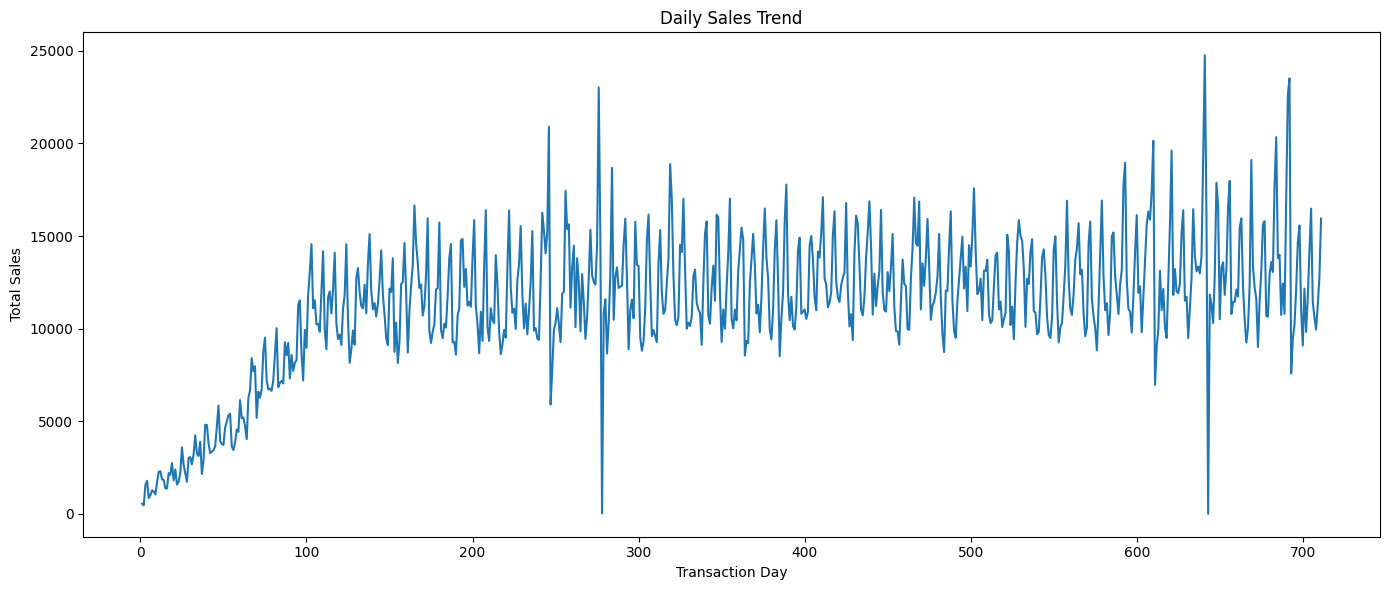

In [37]:
plt.figure(figsize=(14, 6))

plt.plot(
    daily_sales["DAY"],
    daily_sales["sales"]
)

plt.title("Daily Sales Trend")
plt.xlabel("Transaction Day")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()


### 2.6.2 Monthly Sales Trend

Aggregating activity by month reduces daily-level noise and gives us a broader view of changes in sales and purchasing activity over time.


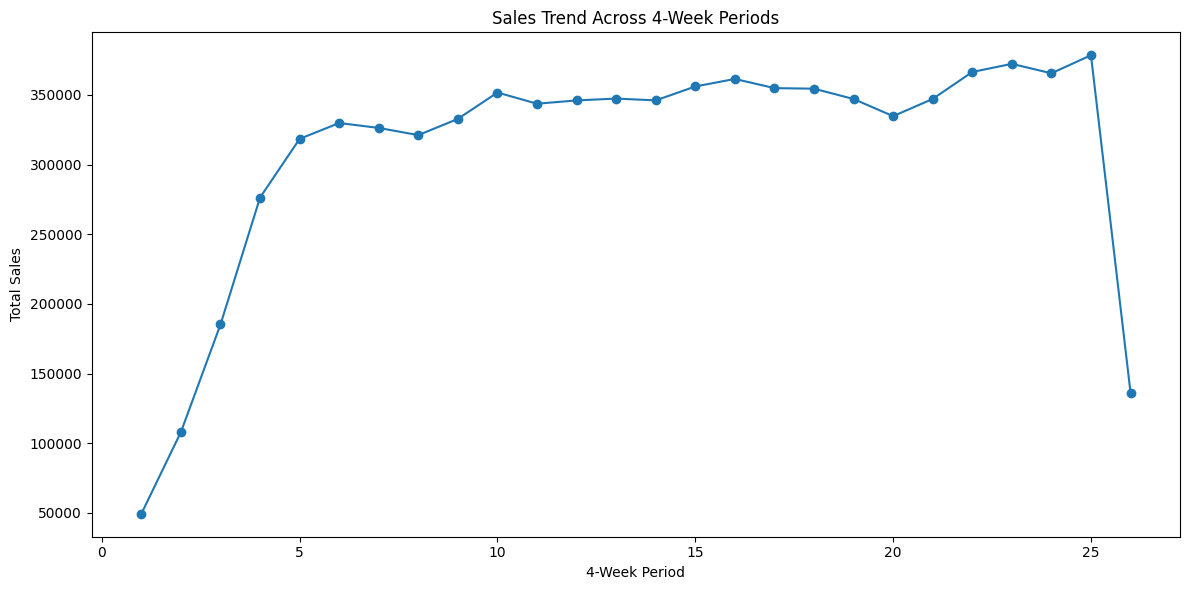

In [38]:
transaction["PERIOD"] = ((transaction["DAY"] - 1) // 28) + 1

period_sales = (
    transaction
    .groupby("PERIOD")
    .agg(sales=("SALES_VALUE", "sum"),
        quantity=("QUANTITY", "sum"),
        transactions=("BASKET_ID", "nunique"))
    .reset_index()
)

plt.figure(figsize=(12, 6))
plt.plot(period_sales["PERIOD"], period_sales["sales"], marker="o")
plt.xlabel("4-Week Period")
plt.ylabel("Total Sales")
plt.title("Sales Trend Across 4-Week Periods")
plt.tight_layout()
plt.show()

## 2.6 Time & Trend Analysis - Insights

At the daily level, sales are naturally volatile, with individual days moving considerably due to weekday/weekend effects and short-term fluctuations. No single day or short window dominates the overall pattern, so daily volatility by itself is not a strong signal for promotional decisions.

Smoothing the data into four-week periods produces a clearer picture. Sales rise sharply across the first ~5 periods and then stabilize in a relatively narrow band of roughly 330K–380K per period. Period 26 is only a partial period because 711 days is not an exact multiple of 28, so it should not be interpreted as a genuine decline.

Overall, the business does not show a strong sustained upward or downward trend after the initial ramp-up. This suggests that the most actionable promotional opportunities are unlikely to come from broad changes in aggregate demand. They are more likely to emerge from differences between households, categories, and campaigns.


## 2.7 Category Performance

The category-level analysis examines which areas contribute most to revenue and which appear more dependent on discounting. This provides a bridge between descriptive sales performance and the later promotional-investment framework.


In [39]:
txn_product = transaction.merge(
    product[["PRODUCT_ID", "DEPARTMENT", "COMMODITY_DESC"]],
    on="PRODUCT_ID", how="left"
)

category_performance = (
    txn_product
    .groupby("COMMODITY_DESC")
    .agg(
        sales=("SALES_VALUE", "sum"),
        quantity=("QUANTITY", "sum"),
        transactions=("BASKET_ID", "nunique"),
        households=("household_key", "nunique"),
        avg_retail_disc=("RETAIL_DISC", "mean")
    )
    .sort_values("sales", ascending=False)
)

category_performance["discount_dependency"] = (
    category_performance["avg_retail_disc"].abs()
    / (category_performance["sales"] / category_performance["quantity"])
)

category_performance.head(20)

,sales,quantity,transactions,households,avg_retail_disc,discount_dependency
COMMODITY_DESC,,,,,,
COUPON/MISC ITEMS,"639,878.56",257218037,27705,1985,-0.73,292.46
SOFT DRINKS,"327,647.30",160637,71699,2405,-0.92,0.45
BEEF,"312,103.22",65576,36733,2238,-1.33,0.28
FLUID MILK PRODUCTS,"205,356.05",116192,69278,2421,-0.55,0.31
CHEESE,"189,528.18",96402,46898,2350,-0.67,0.34
FRZN MEAT/MEAT DINNERS,"160,517.17",79391,22777,2069,-0.83,0.41
BAG SNACKS,"148,375.16",80824,42037,2348,-0.32,0.18
BEERS/ALES,"147,344.45",19863,15527,1606,-0.01,0.00
FROZEN PIZZA,"146,037.25",67225,23174,2052,-0.73,0.33


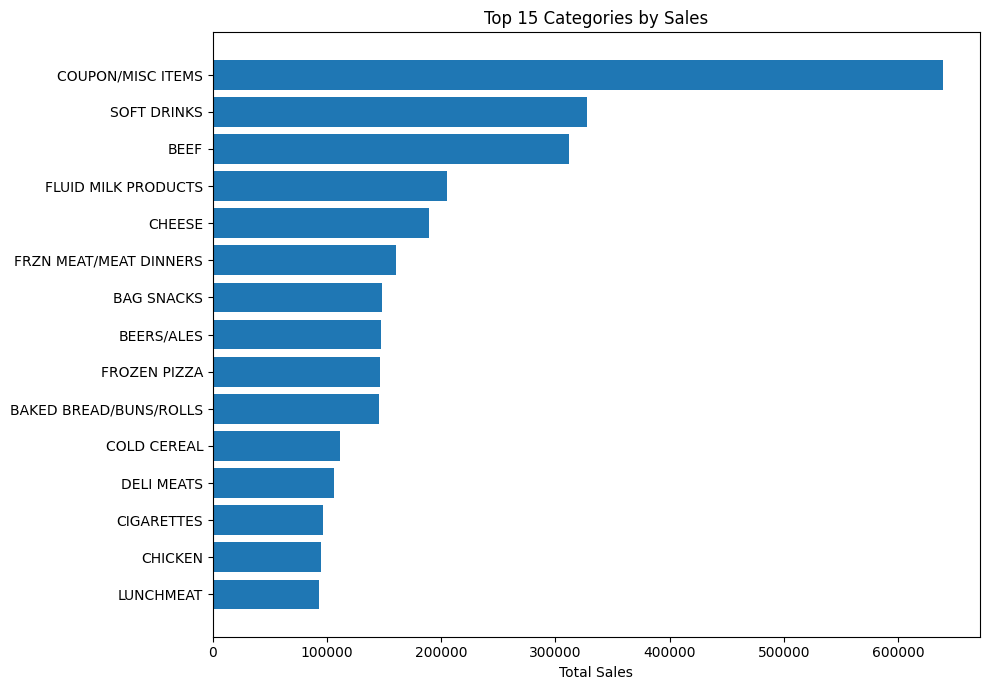

In [40]:
top_categories = category_performance.head(15).sort_values("sales")

plt.figure(figsize=(10, 7))
plt.barh(top_categories.index.astype(str), top_categories["sales"])
plt.title("Top 15 Categories by Sales")
plt.xlabel("Total Sales")
plt.tight_layout()
plt.show()

### 2.7 Category Insights

`COUPON/MISC ITEMS` appears as the highest-sales commodity at approximately $640K, but its extreme quantity and discount-dependency values indicate that it is a data artifact and should not be used for strategic category ranking.

Among the genuine categories, SOFT DRINKS (~$328K), BEEF (~$312K), FLUID MILK PRODUCTS (~$205K), and CHEESE (~$190K) are the largest revenue contributors.

Discount dependency also varies considerably. CHICKEN (0.93), PORK (0.54), ICE CREAM/MILK/SHERBETS (0.52), and SOFT DRINKS (0.45) show relatively high reliance on retail discounts, while BEERS/ALES and CIGARETTES show almost no average discount.

The combination of meaningful revenue and elevated discount dependency makes categories such as Soft Drinks, Chicken, and selected frozen/meat groups potential OPTIMIZE candidates. Higher-revenue categories with lower discount intensity are stronger INVEST/DEFEND candidates once growth is considered.


## 2.8 Campaign & Coupon Response

The analysis now turns to promotional response. Rather than looking only at how many households were targeted, campaign-level coupon redemptions are examined to determine which campaigns generated actual response and whether meaningful differences exist across campaign types.


In [41]:
campaign_full = campaign_table.merge(campaign_desc, on="CAMPAIGN", how="left")

campaign_response = (
    campaign_table.groupby("CAMPAIGN")["household_key"].nunique()
    .to_frame("targeted_households")
    .join(
        coupon_redeem.groupby("CAMPAIGN")["household_key"].nunique()
        .to_frame("redeeming_households")
    )
    .join(campaign_desc.set_index("CAMPAIGN")[["DESCRIPTION"]])
)

campaign_response["redeeming_households"] = campaign_response["redeeming_households"].fillna(0)
campaign_response["redemption_rate"] = (
    campaign_response["redeeming_households"] / campaign_response["targeted_households"]
)

campaign_response.sort_values("redemption_rate", ascending=False)

,targeted_households,redeeming_households,DESCRIPTION,redemption_rate
CAMPAIGN,,,,
18,1133,214,TypeA,0.19
13,1077,196,TypeA,0.18
3,12,2,TypeC,0.17
8,1076,158,TypeA,0.15
25,187,24,TypeB,0.13
23,183,23,TypeB,0.13
15,17,2,TypeC,0.12
19,130,15,TypeB,0.12
9,176,20,TypeB,0.11


In [42]:
overall_redemption_rate = (
    coupon_redeem["household_key"].nunique() / campaign_table["household_key"].nunique()
)
print(f"Overall coupon redemption rate across all campaigns: {overall_redemption_rate:.2%}")

Overall coupon redemption rate across all campaigns: 27.40%


### 2.8 Campaign & Coupon Insights

Type A campaigns stand out in both scale and response. The three largest Type A campaigns (18, 13, and 8) each targeted more than 1,000 households and achieved the highest absolute redemption counts (158-214) as well as strong redemption rates of approximately 15–19%.

Type B and Type C campaigns are smaller and generally show weaker redemption rates, with many below 10% and several in the 2-6% range.

Across households that were targeted by at least one campaign, 27.4% redeemed at least one coupon during the observation period. This is useful as a portfolio-level engagement measure, but it also means that most targeted households did not redeem. Taken together with the stronger response from Type A campaigns, the results suggest an opportunity to concentrate promotional investment on campaign types and customer groups with stronger demonstrated response.


## 2.9 Household Demographic Segments

The demographic view provides an additional layer of context, but it is deliberately treated as supplementary because only 801 of the 2,500 households have demographic information. These characteristics are therefore used to identify directional differences rather than as the primary basis for customer segmentation.


In [43]:
household_demo = household_performance.merge(
    hh_demographic, on="household_key", how="inner" 
)

household_demo.groupby("classification_1")["sales"].agg(["mean", "count"]).sort_values("mean", ascending=False)

,mean,count
classification_1,,
Age Group3,"6,402.82",194
Age Group4,"5,755.09",288
Age Group2,"5,478.42",142
Age Group5,"5,054.73",59
Age Group1,"4,708.33",46
Age Group6,"4,241.03",72


In [44]:
household_demo.groupby("HOMEOWNER_DESC")["sales"].agg(["mean", "count"]).sort_values("mean", ascending=False)

,mean,count
HOMEOWNER_DESC,,
Homeowner,"6,021.80",504
Renter,"5,633.05",42
Probable Owner,"4,955.47",11
Unknown,"4,825.23",233
Probable Renter,"4,304.71",11


### 2.9 Demographic Segment Insights

Among the 801 households with demographic information, Age Group 3 has the highest average sales at approximately $6,403, followed by Age Group 4 at approximately $5,755. Homeowners also spend more on average (~$6,022) than renters (~$5,633) or households with unknown ownership status.

These differences are useful as directional signals, but the limited coverage means demographic characteristics should not drive targeting decisions on their own. Behavioural measures from the transaction data provide a more complete basis for segmentation.


### 2.10 Final EDA Summary

The analysis gives us a clear starting point for the promotional-investment framework.

The dataset covers 2,500 households, approximately 92K products, 30 campaigns, 102 weeks, and about $8.06M in sales. Revenue is moderately concentrated: the top 10% of households generate 34.3% of total sales, leaving a meaningful high-value core alongside a broad customer base.

At the category level, Soft Drinks, Beef, and Fluid Milk are major revenue contributors. Soft Drinks, Chicken, Pork, and selected frozen items also show elevated discount dependency, making them potential OPTIMIZE candidates. Higher-revenue categories with lower discount intensity are stronger INVEST/DEFEND candidates once growth is considered.

Campaign response is strongest among the larger Type A campaigns. The 27.4% figure for households redeeming at least one coupon is useful as a portfolio-level context measure, but it is not a campaign-level redemption rate and will not be used that way in the scoring framework.

Demographic differences are directionally interesting, particularly for Age Group 3 and Homeowners, but demographic coverage is limited to 32% of households. Behavioural segmentation is therefore more reliable for targeting.

Finally, the analysis has identified measurement caveats that need to be addressed before scoring, particularly the unusual quantity behaviour associated with `COUPON/MISC ITEMS` and KIOSK-GAS-related transactions. Promotional findings throughout the notebook remain observational and should not be interpreted as causal evidence of campaign effectiveness.


## 2.11 Scoring Readiness Checks

Before the analytical results are converted into a promotional score, the measurements that could distort the ranking are reviewed. This step focuses on extreme observations, differences in measurement context, and metric definitions that need to be settled before the scoring framework is applied.


### 2.11.1 Product 6534178 - Quantity Treatment

Product 6534178 contributes disproportionately to recorded quantity relative to its sales contribution. We therefore validate its classification and transaction context before allowing quantity to influence household- or category-level scoring.


In [45]:
product.loc[
    product["PRODUCT_ID"] == 6534178,
    product.columns
]

,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
57221,6534178,69,KIOSK-GAS,Private,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,


#### Finding

Product 6534178 is classified under `KIOSK-GAS` with the sub-commodity `GASOLINE-REG UNLEADED`. Its unusually large quantity contribution therefore reflects a different measurement context from typical grocery products rather than an isolated transaction anomaly.

Because raw quantity is not directly comparable between gasoline and unit-based grocery products, it should not be used as an unadjusted cross-product or cross-category scoring measure.

#### Treatment Decision

We retain KIOSK-GAS transactions and sales for revenue and transaction analysis, but exclude KIOSK-GAS quantity from comparable quantity-based scoring. Where quantity is useful, it will be interpreted within comparable product or department contexts rather than across the full dataset.


In [46]:
department_quantity = (
    transaction
    .merge(
        product[["PRODUCT_ID", "DEPARTMENT"]],
        on="PRODUCT_ID",
        how="left"
    )
    .groupby("DEPARTMENT")
    .agg(
        quantity=("QUANTITY", "sum"),
        sales=("SALES_VALUE", "sum"),
        transactions=("BASKET_ID", "nunique")
    )
    .sort_values("quantity", ascending=False)
)

department_quantity["quantity_share"] = (
    department_quantity["quantity"]
    / department_quantity["quantity"].sum()
)

department_quantity["sales_share"] = (
    department_quantity["sales"]
    / department_quantity["sales"].sum()
)

department_quantity.head(10)

,quantity,sales,transactions,quantity_share,sales_share
DEPARTMENT,,,,,
KIOSK-GAS,221254887,"544,222.28",22056,0.85,0.07
MISC SALES TRAN,36080860,"119,960.04",5992,0.14,0.01
GROCERY,2194762,"4,093,814.14",215411,0.01,0.51
DRUG GM,353844,"1,055,358.03",118195,0.00,0.13
PRODUCE,319993,"557,452.11",89026,0.00,0.07
MEAT-PCKGD,148148,"412,436.77",58466,0.00,0.05
MEAT,119113,"548,786.81",53401,0.00,0.07
DELI,67026,"260,866.51",35639,0.00,0.03
PASTRY,49820,"121,739.86",30099,0.00,0.02


#### Department-Level Validation

The department-level analysis confirms that the quantity distortion is structural rather than isolated to Product 6534178. KIOSK-GAS accounts for approximately 85% of recorded quantity but only 7% of sales, while Grocery accounts for approximately 51% of sales but only 1% of recorded quantity.

This confirms that quantity is recorded under materially different measurement contexts across departments and should not be interpreted as a directly comparable unit-volume measure.

#### Final Treatment

All KIOSK-GAS transactions remain in the analytical dataset, and their sales remain valid for revenue and transaction analysis. Raw `QUANTITY` will not be used as a general-purpose scoring variable. Where quantity is analytically useful, it will be evaluated within comparable product or department contexts.


### 2.11.2 Household 1023 - Extreme Behavior Validation

Household 1023 records unusually high transaction and quantity activity. Before using household-level behaviour in the scoring framework, we examine whether this is primarily a consequence of KIOSK-GAS activity or whether the household also shows broad, sustained purchasing behaviour.


In [47]:
hh_1023 = transaction[transaction["household_key"] == 1023]

hh_1023_summary = pd.Series({
    "sales": hh_1023["SALES_VALUE"].sum(),
    "transactions": hh_1023["BASKET_ID"].nunique(),
    "quantity": hh_1023["QUANTITY"].sum(),
    "unique_products": hh_1023["PRODUCT_ID"].nunique(),
    "unique_stores": hh_1023["STORE_ID"].nunique(),
    "active_days": hh_1023["DAY"].nunique()
})

hh_1023_summary

sales                38,319.79
transactions            603.00
quantity          4,479,917.00
unique_products       1,620.00
unique_stores            12.00
active_days             358.00
dtype: float64

In [48]:
hh_1023_product = (
    hh_1023
    .merge(
        product[["PRODUCT_ID", "DEPARTMENT"]],
        on="PRODUCT_ID",
        how="left"
    )
)

hh_1023_gas = hh_1023_product[
    hh_1023_product["DEPARTMENT"] == "KIOSK-GAS"
]

hh_1023_gas_summary = pd.Series({
    "total_sales": hh_1023_product["SALES_VALUE"].sum(),
    "gas_sales": hh_1023_gas["SALES_VALUE"].sum(),
    "gas_sales_share": (
        hh_1023_gas["SALES_VALUE"].sum()
        / hh_1023_product["SALES_VALUE"].sum()
    ),
    "total_quantity": hh_1023_product["QUANTITY"].sum(),
    "gas_quantity": hh_1023_gas["QUANTITY"].sum(),
    "gas_quantity_share": (
        hh_1023_gas["QUANTITY"].sum()
        / hh_1023_product["QUANTITY"].sum()
    ),
    "gas_transactions": hh_1023_gas["BASKET_ID"].nunique()
})

hh_1023_gas_summary

total_sales             38,319.79
gas_sales                  873.34
gas_sales_share              0.02
total_quantity       4,479,917.00
gas_quantity           325,909.00
gas_quantity_share           0.07
gas_transactions            23.00
dtype: float64

In [49]:
hh_1023_department = (
    hh_1023_product
    .groupby("DEPARTMENT")
    .agg(
        quantity=("QUANTITY", "sum"),
        sales=("SALES_VALUE", "sum"),
        transactions=("BASKET_ID", "nunique"),
        products=("PRODUCT_ID", "nunique")
    )
    .sort_values("quantity", ascending=False)
)

hh_1023_department["quantity_share"] = (
    hh_1023_department["quantity"]
    / hh_1023_department["quantity"].sum()
)

hh_1023_department

,quantity,sales,transactions,products,quantity_share
DEPARTMENT,,,,,
MISC SALES TRAN,4147810,"11,161.12",277,8,0.93
KIOSK-GAS,325909,873.34,23,1,0.07
GROCERY,3457,"11,956.01",265,628,0.00
DRUG GM,1237,"5,545.87",221,529,0.00
PRODUCE,507,"1,561.34",114,130,0.00
DELI,244,"1,808.36",70,85,0.00
NUTRITION,141,563.31,42,23,0.00
PASTRY,114,365.27,47,56,0.00
MEAT,105,"1,504.75",40,38,0.00


In [50]:
hh_1023_misc = (
    hh_1023_product[
        hh_1023_product["DEPARTMENT"] == "MISC SALES TRAN"
    ]
    .groupby("PRODUCT_ID")
    .agg(
        quantity=("QUANTITY", "sum"),
        sales=("SALES_VALUE", "sum"),
        transactions=("BASKET_ID", "nunique")
    )
    .sort_values("quantity", ascending=False)
)

hh_1023_misc

,quantity,sales,transactions
PRODUCT_ID,,,
6533889,3742401,"9,444.06",236
6534166,405387,"1,017.44",28
12730170,9,260.55,6
909479,6,28.94,2
882305,2,13.39,2
1049788,2,164.84,2
12729545,2,211.90,1
1021164,1,20.00,1


In [51]:
product.loc[
    product["PRODUCT_ID"].isin([6533889, 6534166]),
    product.columns
]

,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
57181,6533889,69,MISC SALES TRAN,Private,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,
57216,6534166,69,MISC SALES TRAN,Private,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,


### Interpretation

Household 1023 is an extreme-quantity household, but the behaviour is not explained entirely by gasoline purchases. The household is active across 12 stores and 358 days, with 603 transactions and 1,620 unique products, indicating broad and sustained purchasing activity.

At the same time, most of the recorded quantity is concentrated in `MISC SALES TRANS`, particularly two gasoline-coded products. These products contribute substantial recorded quantity but relatively limited sales value.

For this reason, raw quantity is not an appropriate primary measure of household value. Sales value, transaction frequency, category breadth, and campaign response provide more comparable measures of household behaviour and will carry greater weight in the promotional scoring framework.


### 2.11.3 Campaign Redemption Metric - Definition Check

The previously calculated 27.40% redemption rate measures the share of unique households that redeemed at least one coupon among households targeted by at least one campaign across the full campaign period.

This is useful as a portfolio-level descriptive statistic, but it is not a campaign-level redemption rate because a household targeted multiple times and redeeming once is counted only once.

For the scoring framework, redemption will therefore be calculated separately for each campaign. The blended 27.40% figure will remain only as high-level context.


In [52]:
campaign_redemption = (
    campaign_table
    .groupby("CAMPAIGN")
    .agg(
        targeted_households=("household_key", "nunique")
    )
)

# Households that redeemed at least one coupon in each campaign
redeemed_by_campaign = (
    coupon_redeem
    .groupby("CAMPAIGN")["household_key"]
    .nunique()
    .rename("redeemed_households")
)

campaign_redemption = campaign_redemption.join(
    redeemed_by_campaign,
    how="left"
)

campaign_redemption["redeemed_households"] = (
    campaign_redemption["redeemed_households"]
    .fillna(0)
)

campaign_redemption["redemption_rate"] = (
    campaign_redemption["redeemed_households"]
    / campaign_redemption["targeted_households"]
)

campaign_redemption = campaign_redemption.sort_values(
    "redemption_rate",
    ascending=False
)

campaign_redemption

,targeted_households,redeemed_households,redemption_rate
CAMPAIGN,,,
18,1133,214,0.19
13,1077,196,0.18
3,12,2,0.17
8,1076,158,0.15
25,187,24,0.13
23,183,23,0.13
15,17,2,0.12
19,130,15,0.12
9,176,20,0.11


### Interpretation

The campaign-level results show that Campaigns 18, 13, and 8 are the strongest large-scale campaigns, with redemption rates of approximately 18.9%, 18.2%, and 14.7%, respectively.

Campaigns 18 and 13 combine large target populations with the highest absolute redemption volumes, making their results more meaningful for promotional planning than high rates from very small campaigns.

Because small campaigns can produce high redemption rates from limited observations, campaign scale needs to be considered alongside response rate rather than ranking campaigns on redemption rate alone.


### 2.11.4 Scoring Metric Treatment - Final Decisions

The readiness checks lead to a set of measurement rules for the promotional scoring framework:

- Raw quantity will not be used as a primary household-value metric because it is not comparable across departments and is heavily influenced by gasoline and miscellaneous transaction records.
- Household scoring will prioritize sales value, transaction frequency, purchase breadth, and promotional response.
- Campaign performance will be evaluated at the campaign level rather than through the blended 27.40% redemption figure.
- Campaign redemption rate will be considered together with campaign scale so that very small campaigns do not dominate the ranking.
- `COUPON/MISC ITEMS` will be excluded from strategic category ranking because its extreme quantity and sales behaviour indicates a data artifact.
- Demographic variables will remain supplementary because coverage is incomplete.
- Promotional findings remain observational and should not be interpreted as causal evidence of campaign effectiveness.

These decisions give the scoring framework a consistent measurement basis and make the resulting rankings easier to interpret.


## 2.12 Promotional Scoring Framework

With the main analytical results validated, the findings can now be brought together into a promotional scoring framework for household-category-campaign opportunities.

The framework considers three complementary dimensions:

1. **Household Engagement** - how consistently and actively a household shops.
2. **Category Affinity** - where a household shows the strongest purchasing relationship.
3. **Promotional Responsiveness** - the household's demonstrated response to promotional activity.

Campaign-level redemption performance is also retained as a campaign effectiveness signal. Before the components are combined, they are normalized to comparable scales, while the quantity and measurement issues identified above are controlled so that anomalies do not dominate the ranking.


### 2.12.1 Household Engagement Score

Household engagement captures the overall economic value and consistency of a customer's activity. It combines sales value, transaction frequency, and purchase breadth.

Sales value reflects economic contribution, transaction frequency captures consistency, and purchase breadth reflects the diversity of products purchased. Raw quantity is intentionally excluded because the earlier readiness checks showed that it is not comparable across departments and is heavily influenced by gasoline and miscellaneous transaction records.

Each component is normalized to a common 0–100 scale before being combined into the household engagement score.


In [53]:
household_engagement = (
    transaction
    .groupby("household_key")
    .agg(
        sales=("SALES_VALUE", "sum"),
        transactions=("BASKET_ID", "nunique"),
        purchase_breadth=("PRODUCT_ID", "nunique")
    )
)

household_engagement.head()

,sales,transactions,purchase_breadth
household_key,,,
1,"4,330.16",86,677
2,"1,954.34",45,546
3,"2,653.21",47,516
4,"1,200.11",30,164
5,779.06,40,199


In [54]:
household_engagement["sales_score"] = (
    household_engagement["sales"]
    .rank(pct=True) * 100
)

household_engagement["transaction_score"] = (
    household_engagement["transactions"]
    .rank(pct=True) * 100
)

household_engagement["breadth_score"] = (
    household_engagement["purchase_breadth"]
    .rank(pct=True) * 100
)

In [55]:
household_engagement["engagement_score"] = (
    0.40 * household_engagement["sales_score"]
    + 0.30 * household_engagement["transaction_score"]
    + 0.30 * household_engagement["breadth_score"]
)

household_engagement = household_engagement.sort_values(
    "engagement_score",
    ascending=False
)

household_engagement.head(10)

,sales,transactions,purchase_breadth,sales_score,transaction_score,breadth_score,engagement_score
household_key,,,,,,,
2459,"20,671.50",971,3159,99.84,99.84,100.00,99.89
1453,"21,661.29",761,3119,99.88,99.64,99.96,99.83
718,"19,299.86",599,2844,99.76,99.24,99.92,99.65
1653,"19,153.75",541,2407,99.68,98.92,99.80,99.49
1489,"17,251.53",536,2044,99.36,98.88,99.28,99.19
707,"19,194.42",498,1877,99.72,98.60,98.72,99.08
1023,"38,319.79",603,1620,100.00,99.32,96.96,98.88
900,"16,450.53",1223,1641,99.16,99.96,97.24,98.82
232,"12,695.57",631,1931,97.68,99.40,98.96,98.58


### 2.12.2 Category Affinity Score

Category affinity captures the strength of a household's relationship with each department. It combines spending, transaction frequency, and purchase concentration to distinguish categories that are central to a household's behaviour from categories purchased only occasionally.

The purpose is not simply to identify what a household buys, but to identify where its purchasing behaviour is most strongly concentrated.


In [56]:
household_category = (
    transaction
    .merge(
        product[["PRODUCT_ID", "DEPARTMENT"]],
        on="PRODUCT_ID",
        how="left"
    )
    .groupby(["household_key", "DEPARTMENT"])
    .agg(
        sales=("SALES_VALUE", "sum"),
        transactions=("BASKET_ID", "nunique"),
        quantity=("QUANTITY", "sum"),
        products=("PRODUCT_ID", "nunique")
    )
    .reset_index()
)

artifact_departments = [
    "MISC SALES TRAN",
    "KIOSK-GAS",
    "MISC. TRANS."
]
household_category = household_category[
    ~household_category["DEPARTMENT"].isin(artifact_departments)
].copy()

department_counts = household_category.groupby("DEPARTMENT")["household_key"].nunique()
print("Department household-count distribution:")
print(department_counts.describe())

eligible_departments = department_counts[department_counts >= 100].index
excluded_small_departments = department_counts[department_counts < 100]
print(f"\nExcluding {len(excluded_small_departments)} departments with fewer than 100 households:")
print(excluded_small_departments.sort_values(ascending=False))

household_category = household_category[
    household_category["DEPARTMENT"].isin(eligible_departments)
].copy()

household_category.head(10)

Department household-count distribution:
count      41.00
mean      700.71
std       918.18
min         1.00
25%         4.00
50%       149.00
75%     1,286.00
max     2,500.00
Name: household_key, dtype: float64

Excluding 20 departments with fewer than 100 households:
DEPARTMENT
AUTOMOTIVE         61
DAIRY DELI         50
GM MERCH EXP       33
CNTRL/STORE SUP    20
PHOTO              17
RX                 14
POSTAL CENTER      12
DELI/SNACK BAR     10
MEAT-WHSE           5
TOYS                4
PHARMACY SUPPLY     4
HBC                 4
VIDEO RENTAL        3
VIDEO               3
CHARITABLE CONT     2
PROD-WHS SALES      2
PORK                2
HOUSEWARES          1
ELECT &PLUMBING     1
GRO BAKERY          1
Name: household_key, dtype: int64


,household_key,DEPARTMENT,sales,transactions,quantity,products
0,1,,0.00,13,0,2
1,1,DELI,212.17,42,68,34
2,1,DRUG GM,530.89,60,201,93
3,1,FLORAL,7.99,1,1,1
4,1,GROCERY,"2,755.00",73,1310,445
5,1,MEAT,17.91,4,5,4
6,1,MEAT-PCKGD,331.09,50,117,31
8,1,NUTRITION,48.33,15,19,5
9,1,PASTRY,95.31,24,49,19
10,1,PRODUCE,266.10,51,209,39


### 2.12.2 Category Affinity Score - Calculation

For each household-category combination, sales, transaction frequency, purchase quantity, and product breadth are normalized to a common 0–100 scale. These components are then combined to measure how strongly the household engages with that department relative to other households.

Quantity is retained here only within the controlled category context established by the scoring-readiness checks.


In [57]:

household_category["sales_score"] = (
    household_category.groupby("DEPARTMENT")["sales"].rank(pct=True) * 100
)

household_category["transaction_score"] = (
    household_category.groupby("DEPARTMENT")["transactions"].rank(pct=True) * 100
)

household_category["quantity_score"] = (
    household_category.groupby("DEPARTMENT")["quantity"].rank(pct=True) * 100
)

household_category["breadth_score"] = (
    household_category.groupby("DEPARTMENT")["products"].rank(pct=True) * 100
)

household_category["category_affinity_score"] = (
    0.30 * household_category["sales_score"]
    + 0.25 * household_category["transaction_score"]
    + 0.25 * household_category["quantity_score"]
    + 0.20 * household_category["breadth_score"]
)

household_category = household_category.sort_values(
    "category_affinity_score",
    ascending=False
)

household_category.head(10)

,household_key,DEPARTMENT,sales,transactions,quantity,products,sales_score,transaction_score,quantity_score,breadth_score,category_affinity_score
13236,1023,GARDEN CENTER,936.67,17,97,15,100.00,100.00,100.00,100.00,100.00
15832,1228,SEAFOOD,702.44,138,189,53,100.00,100.00,100.00,100.00,100.00
24531,1907,RESTAURANT,166.45,41,54,18,100.00,100.00,100.00,100.00,100.00
30063,2322,PASTRY,855.95,132,368,114,100.00,99.91,100.00,100.00,99.98
26908,2085,COSMETICS,461.79,50,101,74,99.92,100.00,100.00,100.00,99.98
13235,1023,FLORAL,877.12,37,93,36,100.00,99.92,100.00,99.92,99.96
11003,855,FLORAL,448.86,47,76,44,99.83,100.00,99.92,100.00,99.93
31870,2459,GROCERY,"11,786.77",669,6481,2052,99.92,99.84,99.96,100.00,99.93
22735,1769,SEAFOOD-PCKGD,"1,014.64",57,131,28,100.00,99.88,100.00,99.70,99.91
21240,1653,MEAT-PCKGD,"1,662.15",162,489,118,100.00,99.96,99.92,99.58,99.89


### 2.12.3 Campaign Alignment Score

Campaign alignment measures how strongly a household has responded to the promotional campaigns it was exposed to. Campaign exposure and redemption behaviour are combined to identify households with stronger demonstrated promotional engagement.


In [58]:
campaign_household = (
    campaign_table
    .merge(
        coupon_redeem[["household_key", "CAMPAIGN"]].drop_duplicates(),
        on=["household_key", "CAMPAIGN"],
        how="left",
        indicator=True
    )
)

campaign_household["redeemed"] = (
    campaign_household["_merge"] == "both"
).astype(int)

campaign_household = (
    campaign_household
    .groupby("household_key")
    .agg(
        campaigns_targeted=("CAMPAIGN", "nunique"),
        campaigns_redeemed=("redeemed", "sum")
    )
)

campaign_household["redemption_rate"] = (
    campaign_household["campaigns_redeemed"]
    / campaign_household["campaigns_targeted"]
)

campaign_household.head()

,campaigns_targeted,campaigns_redeemed,redemption_rate
household_key,,,
1,8,2,0.25
2,1,0,0.00
3,3,0,0.00
4,1,0,0.00
6,4,0,0.00


In [59]:
campaign_household["campaign_score"] = (
    campaign_household["redemption_rate"] * 100
)

campaign_household.head()

,campaigns_targeted,campaigns_redeemed,redemption_rate,campaign_score
household_key,,,,
1,8,2,0.25,25.00
2,1,0,0.00,0.00
3,3,0,0.00,0.00
4,1,0,0.00,0.00
6,4,0,0.00,0.00


In [60]:
# Calculate overall campaign redemption rate
campaign_household["redemption_rate"] = (
    campaign_household["campaigns_redeemed"]
    / campaign_household["campaigns_targeted"]
)

# Apply a simple reliability adjustment
campaign_household["campaign_score"] = (
    campaign_household["redemption_rate"] * 100
    * (
        campaign_household["campaigns_targeted"]
        / (
            campaign_household["campaigns_targeted"] + 5
        )
    )
)

campaign_household = campaign_household.sort_values(
    "campaign_score",
    ascending=False
)

campaign_household.head(10)

,campaigns_targeted,campaigns_redeemed,redemption_rate,campaign_score
household_key,,,,
367,9,9,1.00,64.29
256,12,10,0.83,58.82
67,8,7,0.88,53.85
22,8,7,0.88,53.85
2451,9,7,0.78,50.00
889,12,8,0.67,47.06
13,10,7,0.70,46.67
464,10,7,0.70,46.67
1726,8,6,0.75,46.15


## 2.12.4 Overall Promotional Score


The overall promotional score brings household engagement, category affinity, and campaign alignment together into a single measure of promotional opportunity.

Engagement captures overall purchasing intensity, category affinity identifies where a household is most strongly connected, and campaign alignment captures historical promotional responsiveness. The components are weighted so that no single dimension overwhelms the others and the final score remains useful for identifying households with both commercial value and a relevant promotional signal.


### 2.12.4 Integrated Promotional Opportunity Score

We combine the household engagement and category affinity measures with household-level promotional response to identify high-potential household-category opportunities. The campaign identifier is retained so that the resulting output can later support campaign-specific targeting and recommendations.


In [61]:
promotional_score = (
    campaign_table[
        ["household_key", "CAMPAIGN", "DESCRIPTION"]
    ]
    .merge(
        household_category[
            [
                "household_key",
                "DEPARTMENT",
                "category_affinity_score"
            ]
        ],
        on="household_key",
        how="inner"
    )
    .merge(
        household_engagement[
            ["engagement_score"]
        ],
        left_on="household_key",
        right_index=True,
        how="left"
    )
)

promotional_score.head(10)

,household_key,CAMPAIGN,DESCRIPTION,DEPARTMENT,category_affinity_score,engagement_score
0,17,26,TypeA,MEAT,94.08,67.54
1,17,26,TypeA,SEAFOOD-PCKGD,91.41,67.54
2,17,26,TypeA,DRUG GM,70.92,67.54
3,17,26,TypeA,PRODUCE,70.01,67.54
4,17,26,TypeA,MEAT-PCKGD,67.07,67.54
5,17,26,TypeA,GROCERY,66.55,67.54
6,17,26,TypeA,PASTRY,35.10,67.54
7,17,26,TypeA,NUTRITION,34.16,67.54
8,17,26,TypeA,DELI,29.36,67.54
9,27,26,TypeA,DRUG GM,96.63,80.50


In [62]:
promotional_score = (
    promotional_score
    .merge(
        campaign_household[
            ["campaign_score"]
        ],
        left_on="household_key",
        right_index=True,
        how="left"
    )
)

promotional_score.head(10)

,household_key,CAMPAIGN,DESCRIPTION,DEPARTMENT,category_affinity_score,engagement_score,campaign_score
0,17,26,TypeA,MEAT,94.08,67.54,0.00
1,17,26,TypeA,SEAFOOD-PCKGD,91.41,67.54,0.00
2,17,26,TypeA,DRUG GM,70.92,67.54,0.00
3,17,26,TypeA,PRODUCE,70.01,67.54,0.00
4,17,26,TypeA,MEAT-PCKGD,67.07,67.54,0.00
5,17,26,TypeA,GROCERY,66.55,67.54,0.00
6,17,26,TypeA,PASTRY,35.10,67.54,0.00
7,17,26,TypeA,NUTRITION,34.16,67.54,0.00
8,17,26,TypeA,DELI,29.36,67.54,0.00
9,27,26,TypeA,DRUG GM,96.63,80.50,0.00


In [63]:
campaign_household.loc[
    [367, 256, 67, 22, 2451],
    [
        "campaigns_targeted",
        "campaigns_redeemed",
        "redemption_rate",
        "campaign_score"
    ]
]

,campaigns_targeted,campaigns_redeemed,redemption_rate,campaign_score
household_key,,,,
367,9,9,1.00,64.29
256,12,10,0.83,58.82
67,8,7,0.88,53.85
22,8,7,0.88,53.85
2451,9,7,0.78,50.00


In [64]:
campaign_household[
    ["campaigns_targeted", "campaigns_redeemed", "campaign_score"]
].sort_values("campaign_score", ascending=False).head(20)

,campaigns_targeted,campaigns_redeemed,campaign_score
household_key,,,
367,9,9,64.29
256,12,10,58.82
67,8,7,53.85
22,8,7,53.85
2451,9,7,50.00
889,12,8,47.06
13,10,7,46.67
464,10,7,46.67
1726,8,6,46.15


### 2.12.4 Integrated Promotional Opportunity Score - Revision

A review of the first scoring version revealed two issues that could materially distort the ranking.

First, engagement scores were being lost for households that had never been targeted by a campaign. The merge pulled `engagement_score` from `promotional_score`, which only contains households present in `campaign_table`. As a result, never-targeted households could receive `NaN -> 0` even when their underlying engagement score had already been calculated for all 2,500 households. This was particularly problematic because the framework is intended to identify valuable customers who may represent untapped promotional opportunities.

Second, the three score components were on incompatible scales. `campaign_score` averaged roughly 3, compared with averages of about 33 for `category_affinity_score` and 41 for `engagement_score`. An unweighted sum would therefore give campaign responsiveness very little influence.

The revised approach addresses both issues by sourcing engagement from the complete household table, retaining each household's strongest category affinity, converting the three components to comparable percentile scales, and then combining them with explicit weights.


#### Step 1 - Rebuild `household_score_data` with the correct engagement scores

The engagement score is now taken directly from `household_engagement`, which was calculated across all 2,500 households in section 2.12.1. It is no longer taken from the campaign-filtered `promotional_score` table.


In [65]:
household_score_data = household_performance.copy()

household_score_data = household_score_data.merge(
    campaign_household[["campaign_score"]],
    left_index=True,
    right_index=True,
    how="left"
)
household_score_data["campaign_score"] = household_score_data["campaign_score"].fillna(0)


household_score_data = household_score_data.merge(
    household_engagement[["engagement_score"]],
    left_index=True,
    right_index=True,
    how="left"
)

print("Missing engagement scores after fix:", household_score_data["engagement_score"].isna().sum())
household_score_data.head()

Missing engagement scores after fix: 0


,sales,quantity,transactions,sales_per_transaction,quantity_per_transaction,value_segment,campaign_score,engagement_score
household_key,,,,,,,,
1,"4,330.16",1997,86,50.35,23.22,High Value - Frequent,15.38,66.35
2,"1,954.34",834,45,43.43,18.53,Low Value,0.00,45.12
3,"2,653.21",8540,47,56.45,181.70,High Value - Less Frequent,0.00,49.74
4,"1,200.11",382,30,40.00,12.73,Low Value,0.00,22.93
5,779.06,245,40,19.48,6.12,Low Value,0.00,22.34


#### Step 2 - Keep each household's strongest category affinity

Averaging category affinity across every department a household touches would flatten the signal we need: the category to which the household is most strongly connected.

We therefore carry forward each household's single strongest-affinity category, while retaining the full `household_category` table separately for the later campaign-scenario stage where category-specific targeting is required.


In [66]:
best_category_affinity = (
    household_category
    .sort_values("category_affinity_score", ascending=False)
    .groupby("household_key")
    .first()[["DEPARTMENT", "category_affinity_score"]]
    .rename(columns={"DEPARTMENT": "top_affinity_category"})
)

household_score_data = household_score_data.merge(
    best_category_affinity,
    left_index=True,
    right_index=True,
    how="left"
)

household_score_data["category_affinity_score"] = household_score_data["category_affinity_score"].fillna(0)
household_score_data["top_affinity_category"] = household_score_data["top_affinity_category"].fillna("None")

household_score_data.isna().sum()

sales                       0
quantity                    0
transactions                0
sales_per_transaction       0
quantity_per_transaction    0
value_segment               0
campaign_score              0
engagement_score            0
top_affinity_category       0
category_affinity_score     0
dtype: int64

In [67]:
household_score_data.shape

(2500, 10)

#### Step 3 - Re-rank the three components to comparable percentile scales

`campaign_score` is based on redemption behaviour and has a mean of roughly 3, while `category_affinity_score` and `engagement_score` are already on percentile-based scales. To make the components comparable, `campaign_score` is re-ranked to a 0-100 percentile before the scores are combined.

There is one additional issue: campaign score is zero-inflated because most households have never redeemed a coupon. A standard `.rank(pct=True)` would assign tied zero values an average rank rather than a true zero, placing households with no promotional history around the middle of the distribution.

The revised calculation therefore assigns the zero group an explicit score of 0 and ranks only households with non-zero promotional history against one another. This keeps the promotional-response signal faithful to the underlying behaviour.


In [68]:
is_zero = household_score_data["campaign_score"] == 0

household_score_data["campaign_score_pct"] = 0.0
household_score_data.loc[~is_zero, "campaign_score_pct"] = (
    household_score_data.loc[~is_zero, "campaign_score"].rank(pct=True) * 100
)

household_score_data["category_affinity_pct"] = (
    household_score_data["category_affinity_score"].rank(pct=True) * 100
)

household_score_data["engagement_pct"] = (
    household_score_data["engagement_score"].rank(pct=True) * 100
)

household_score_data[
    ["campaign_score", "campaign_score_pct",
     "category_affinity_score", "category_affinity_pct",
     "engagement_score", "engagement_pct"]
].describe()

,campaign_score,campaign_score_pct,category_affinity_score,category_affinity_pct,engagement_score,engagement_pct
count,"2,500.00","2,500.00","2,500.00","2,500.00","2,500.00","2,500.00"
mean,3.09,8.70,74.02,50.02,50.02,50.02
std,8.03,22.47,22.64,28.87,27.65,28.87
min,0.00,0.00,0.66,0.04,0.05,0.04
25%,0.00,0.00,61.12,25.03,26.52,25.03
50%,0.00,0.00,80.45,50.02,50.76,50.02
75%,0.00,0.00,92.29,75.01,73.81,75.01
max,64.29,100.00,100.00,99.96,99.89,100.00


#### Step 4 - Combine the components using explicit weights

The final weights reflect the role each component plays in a promotional decision:

- **Engagement (35%)** captures overall value and consistency and provides the foundation for deciding whether a household is worth investing in.
- **Category affinity (30%)** identifies where that household is most strongly engaged, which makes the score actionable for category-level targeting.
- **Campaign score (35%)** provides the strongest direct historical evidence of promotional responsiveness, so it receives equal weight to engagement rather than being diluted by the other components.

The weights are stated explicitly so that the scoring framework remains transparent and can be adjusted later if the business objective changes.


In [69]:
household_score_data["promotional_opportunity_score"] = (
    0.35 * household_score_data["engagement_pct"]
    + 0.30 * household_score_data["category_affinity_pct"]
    + 0.35 * household_score_data["campaign_score_pct"]
)

household_score_data[
    [
        "campaign_score_pct",
        "category_affinity_pct",
        "engagement_pct",
        "promotional_opportunity_score"
    ]
].describe()

,campaign_score_pct,category_affinity_pct,engagement_pct,promotional_opportunity_score
count,"2,500.00","2,500.00","2,500.00","2,500.00"
mean,8.70,50.02,50.02,35.56
std,22.47,28.87,28.87,22.37
min,0.00,0.04,0.04,0.04
25%,0.00,25.03,25.03,16.91
50%,0.00,50.02,50.02,33.42
75%,0.00,75.01,75.01,51.94
max,100.00,99.96,100.00,97.10


In [70]:
household_score_data.reset_index()[
    [
        "household_key",
        "value_segment",
        "top_affinity_category",
        "campaign_score_pct",
        "category_affinity_pct",
        "engagement_pct",
        "promotional_opportunity_score"
    ]
].sort_values(
    "promotional_opportunity_score",
    ascending=False
).head(20)

,household_key,value_segment,top_affinity_category,campaign_score_pct,category_affinity_pct,engagement_pct,promotional_opportunity_score
978,979,High Value - Frequent,NUTRITION,96.89,97.80,96.72,97.10
2279,2280,High Value - Frequent,COSMETICS,94.70,99.64,96.44,96.79
388,389,High Value - Frequent,PRODUCE,95.39,96.44,97.88,96.58
981,982,High Value - Frequent,DRUG GM,93.09,95.76,99.20,96.03
1822,1823,High Value - Frequent,DELI,97.81,91.28,97.76,95.83
1632,1633,High Value - Frequent,DELI,91.71,97.44,95.72,94.83
114,115,High Value - Frequent,SEAFOOD-PCKGD,95.39,93.68,95.00,94.74
1097,1098,High Value - Frequent,SPIRITS,91.24,97.20,95.84,94.64
12,13,High Value - Frequent,DRUG GM,98.50,88.92,95.12,94.44
1725,1726,High Value - Frequent,NUTRITION,97.81,95.20,90.36,94.42


#### Step 5 - Sanity check previously zeroed, never-targeted households

We then verify that households with no campaign history are no longer being assigned artificial zero values for engagement or category affinity. Where the underlying purchasing behaviour supports it, these households should now receive meaningful scores and become visible as potential untapped opportunities.


In [71]:
# Households never targeted by any campaign 
never_targeted = household_score_data[household_score_data["campaign_score"] == 0]

never_targeted[
    ["sales", "transactions", "value_segment", "engagement_pct", "category_affinity_pct", "promotional_opportunity_score"]
].sort_values("promotional_opportunity_score", ascending=False).head(10)

,sales,transactions,value_segment,engagement_pct,category_affinity_pct,promotional_opportunity_score
household_key,,,,,,
2459,"20,671.50",971,High Value - Frequent,100.00,99.76,64.93
1023,"38,319.79",603,High Value - Frequent,99.76,99.96,64.90
900,"16,450.53",1223,High Value - Frequent,99.72,99.24,64.67
1489,"17,251.53",536,High Value - Frequent,99.84,98.48,64.49
707,"19,194.42",498,High Value - Frequent,99.80,98.28,64.41
1510,"11,211.37",1300,High Value - Frequent,98.60,98.84,64.16
328,"17,332.13",239,High Value - Frequent,97.92,99.52,64.13
591,"13,534.93",325,High Value - Frequent,98.32,98.92,64.09
2312,"14,682.81",321,High Value - Frequent,98.12,99.08,64.07


#### Step 6 - Segment-level summary

With the corrected scores in place, we rerun the segment-level summary to understand where the strongest promotional opportunities sit across the customer base.


In [72]:
segment_promo = (
    household_score_data
    .groupby("value_segment")
    .agg(
        households=("promotional_opportunity_score", "size"),
        avg_opportunity_score=("promotional_opportunity_score", "mean"),
        median_opportunity_score=("promotional_opportunity_score", "median"),
        total_sales=("sales", "sum"),
        avg_campaign_score_pct=("campaign_score_pct", "mean"),
        avg_category_affinity_pct=("category_affinity_pct", "mean"),
        avg_engagement_pct=("engagement_pct", "mean")
    )
    .sort_values("avg_opportunity_score", ascending=False)
)

segment_promo["household_share_pct"] = (
    segment_promo["households"] / segment_promo["households"].sum() * 100
).round(2)

segment_promo["sales_share_pct"] = (
    segment_promo["total_sales"] / segment_promo["total_sales"].sum() * 100
).round(2)

segment_summary = (
    segment_promo
    .reset_index()
    [
        [
            "value_segment",
            "households",
            "household_share_pct",
            "avg_opportunity_score",
            "total_sales",
            "sales_share_pct",
            "avg_campaign_score_pct",
            "avg_category_affinity_pct",
            "avg_engagement_pct"
        ]
    ]
    .sort_values("avg_opportunity_score", ascending=False)
)

segment_summary

,value_segment,households,household_share_pct,avg_opportunity_score,total_sales,sales_share_pct,avg_campaign_score_pct,avg_category_affinity_pct,avg_engagement_pct
0,High Value - Frequent,1050,42.00,55.74,"6,152,810.71",76.36,17.43,74.23,78.21
1,High Value - Less Frequent,200,8.00,39.38,"642,949.32",7.98,9.49,55.99,55.04
2,Low Value - Frequent,205,8.20,31.45,"326,005.99",4.05,4.60,46.12,45.73
3,Low Value,1045,41.80,15.35,"935,697.06",11.61,0.58,25.31,21.58


### Key Insights – Promotional Opportunity Segmentation

The corrected scoring framework identifies a specific group of high-value households that have no recorded campaign redemption history. Household 2459 ranks highest within this untapped group with a promotional opportunity score of 64.92, supported by $20,671.50 in sales, 971 transactions, 100th-percentile engagement, and more than half of its spending concentrated in GROCERY at $11,786.77. Nine additional households - 1023, 900, 1510, 1489, 707, 909, 328, 591, and 2312 - score between 64.0 and 64.9.

This should be interpreted as an untapped-group ranking rather than a claim that these households are the highest-scoring customers overall. The global maximum opportunity score is 97.10 and is driven by households with established coupon redemption behaviour. The ten households identified here are specifically the strongest opportunities among customers with zero recorded promotional history.

All ten belong to the High Value - Frequent segment, which represents 42.0% of households but 76.36% of total sales ($6.15M). They are therefore not a separate customer segment; they are the highest-value part of an already strong segment that has not yet demonstrated campaign response.


## 2.13 Overall Business Insights & Recommendations

The analysis brings the behavioural, category, campaign, and scoring results together into a set of practical conclusions.

### Key Business Insights

1. **A specific, high-value untapped household group exists.** Ten households, led by 2459, 1023, and 900, combine strong engagement and category affinity with zero recorded campaign redemption. Their promotional opportunity scores range from 64.0 to 64.9, compared with a 55.74 average for the High Value - Frequent segment. This gives the business a specific, evidence-backed target for a first-time campaign rather than a broad segment assumption.

2. **High-value customers drive the majority of revenue.** High Value - Frequent households represent 42.0% of the customer base but generate 76.36% of total sales, or approximately $6.15M of the $8.06M total.

3. **Frequency separates two different high-value opportunities.** High Value - Less Frequent households represent 8.0% of the base and have an average opportunity score of 39.37. They still carry meaningful value, but their lower purchase frequency makes them better candidates for reactivation or frequency-building strategies than the untapped-but-frequent households identified above.

4. **Low-value households warrant selective rather than broad investment.** Low Value households represent 41.8% of the base but only 11.61% of sales and have the lowest average opportunity score at 15.36. Broad promotion across this group is therefore less attractive than targeted, low-cost engagement.

### Overall Recommendation

The clearest near-term opportunity is targeted outreach to the ten high-engagement households with zero campaign history. This is a specific opportunity supported by the scoring framework rather than a general assumption about an entire customer segment.

Beyond this group, promotional investment should remain differentiated: retention-focused for High Value - Frequent households, frequency-building for High Value - Less Frequent households, and selective or low-cost engagement for Low Value households. This is preferable to applying a uniform discounting strategy across the full customer base.


In [73]:
household_score_data[
    household_score_data.index.isin(
        [2459, 1023, 900, 1489, 707, 909, 1510, 328, 591, 2312]
    )
][["sales", "value_segment"]]

,sales,value_segment
household_key,,
328,"17,332.13",High Value - Frequent
591,"13,534.93",High Value - Frequent
707,"19,194.42",High Value - Frequent
900,"16,450.53",High Value - Frequent
909,"12,414.56",High Value - Frequent
1023,"38,319.79",High Value - Frequent
1489,"17,251.53",High Value - Frequent
1510,"11,211.37",High Value - Frequent
2312,"14,682.81",High Value - Frequent
